<a href="https://colab.research.google.com/github/m-ony/mineria-de-datos/blob/main/Clasificaci%C3%B3n_de_D%C3%ADgitos_Manuscritos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Actividad: Clasificación de Dígitos Manuscritos con Minería de Datos

##1. Carga del dataset  
Importar el dataset Digits desde sklearn.  
Visualizar algunas imágenes.  
Dividir los datos en entrenamiento y prueba (80/20).  

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [6]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

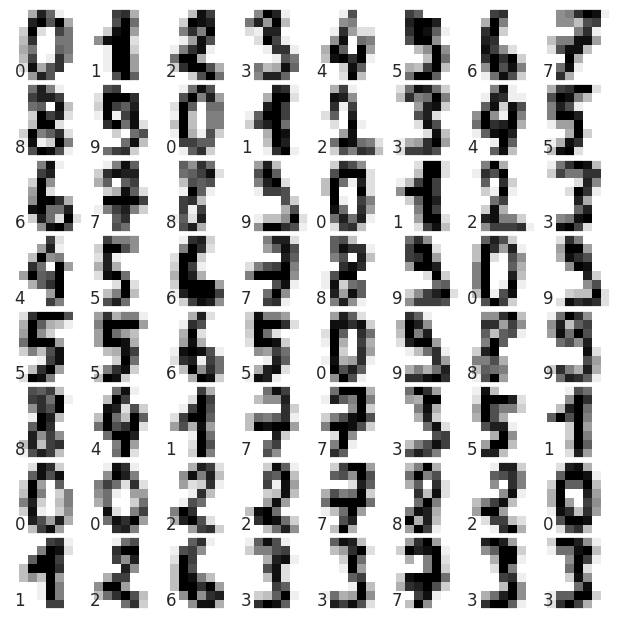

In [7]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

In [10]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target, test_size=0.2,
                                                random_state=42)

##2. Entrenamiento de modelos
Entrenar los siguientes modelos:

KNN (k=3 o k=5)  
SVM (kernel RBF)  
Random Forest (100 estimadores)

**Entrenamiento con KNN**

In [29]:
from sklearn.preprocessing import StandardScaler
#escalar los datos, es decir poner todo en la misma escala
scaler = StandardScaler()

Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [30]:
# Modelo k-NN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(Xtrain, ytrain)

KNeighborsClassifier(n_neighbors=3)

**Entrenamiento con SVM**

**Entrenamiento con Random Forest**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Crear el modelo
model = RandomForestClassifier(n_estimators=1000)
# Entrenar con el conjunto de entrenamiento
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

##3. Evaluación   
Calcular exactitud (accuracy) sobre el conjunto de prueba.  
Comparar resultados y determinar el mejor modelo.  

In [26]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.93      0.97        30
           2       1.00      1.00      1.00        33
           3       0.94      1.00      0.97        32
           4       1.00      0.98      0.99        47
           5       0.98      0.94      0.96        49
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.93      0.97      0.95        29
           9       0.95      0.97      0.96        39

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [ ]:
from sklearn.metrics import accuracy_score

# Evaluar k-NN
y_pred_knn = knn.predict(Xtest)
acc_knn = accuracy_score(ytest, y_pred_knn)

# Evaluar Random Forest
y_pred_rf = rf.predict(Xtest)
acc_rf = accuracy_score(ytest, y_pred_rf)

# Evaluar SVM
y_pred_svm = svm.predict(Xtest)
acc_svm = accuracy_score(ytest, y_pred_svm)